In [1]:
# ============================================
# Mumbai Local - ML Model Training
# Step 3: Crowd Prediction Model
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')


In [2]:
# ============================================
# STEP 1 — DATA LOAD KARO
# ============================================
# Kyun? → Wahi clean dataset jo humne EDA mein
#          verify kiya tha, usi pe model train karenge

print("=" * 50)
print("STEP 1 — LOADING DATA")
print("=" * 50)

df = pd.read_csv("data/mumbai_local_crowd_data.csv")
print(f"\n✅ Data Loaded : {len(df):,} rows, {len(df.columns)} columns")

STEP 1 — LOADING DATA

✅ Data Loaded : 709,560 rows, 13 columns


In [3]:
# ============================================
# STEP 2 — FEATURES AUR TARGET ALAG KARO
# ============================================
# Kyun? → Model ko batana hai ki INPUT (Features) kya hai
#          aur OUTPUT (Target) kya predict karna hai

print("\n" + "=" * 50)
print("STEP 2 — SEPARATING FEATURES & TARGET")
print("=" * 50)

# Features (Inputs) — jo model ko diya jayega
feature_columns = [
    'day_of_week', 'hour', 'month', 'is_monsoon',
    'is_holiday', 'line', 'station_from', 'station_to',
    'train_type', 'coach_number'
]

# Target (Output) — jo predict karna hai
target_column = 'crowd_percent'

X = df[feature_columns].copy()
y = df[target_column].copy()

print(f"\n📥 Features (X) : {feature_columns}")
print(f"🎯 Target (y)   : {target_column}")
print(f"\n📊 X Shape : {X.shape}")
print(f"📊 y Shape : {y.shape}")


STEP 2 — SEPARATING FEATURES & TARGET

📥 Features (X) : ['day_of_week', 'hour', 'month', 'is_monsoon', 'is_holiday', 'line', 'station_from', 'station_to', 'train_type', 'coach_number']
🎯 Target (y)   : crowd_percent

📊 X Shape : (709560, 10)
📊 y Shape : (709560,)


In [4]:
# ============================================
# STEP 3 — CATEGORICAL DATA ENCODE KARO
# ============================================
# Kyun? → Model sirf NUMBERS samajhta hai
#          "Western", "Borivali", "Fast" jaise text
#          ko number mein convert karna padega
#
# Hum LabelEncoder use kar rahe hain:
# Western → 0, Central → 1, Harbour → 2 (example)

print("\n" + "=" * 50)
print("STEP 3 — ENCODING CATEGORICAL COLUMNS")
print("=" * 50)

categorical_columns = ['line', 'station_from', 'station_to', 'train_type']

# Har categorical column ke liye alag encoder banayenge
# Kyun alag? → Kyunki "Borivali" station_from mein bhi hai
#               aur station_to mein bhi — alag encoding chahiye
encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le   # Encoder save kar rahe hain baad mein use ke liye
    print(f"✅ Encoded: {col}  →  {len(le.classes_)} unique values")

print(f"\n👀 Encoded Data Preview:")
print(X.head())


STEP 3 — ENCODING CATEGORICAL COLUMNS
✅ Encoded: line  →  3 unique values
✅ Encoded: station_from  →  69 unique values
✅ Encoded: station_to  →  73 unique values
✅ Encoded: train_type  →  3 unique values

👀 Encoded Data Preview:
   day_of_week  hour  month  is_monsoon  is_holiday  line  station_from  \
0            6     6      1           0           0     2             6   
1            6     6      1           0           0     2             6   
2            6     6      1           0           0     2             6   
3            6     6      1           0           0     2             6   
4            6     6      1           0           0     2             6   

   station_to  train_type  coach_number  
0          15           0             1  
1          15           0             2  
2          15           0             3  
3          15           0             4  
4          15           0             5  


In [5]:
# ============================================
# STEP 4 — TRAIN-TEST SPLIT
# ============================================
# Kyun? → Model ko POORA data train ke liye nahi denge
#          Kuch data "chhupa" ke rakhenge taaki baad mein
#          test kar sakein ki model NAYE data pe kaisa
#          perform karta hai (jaise exam ka unseen paper)
#
# 80% Training, 20% Testing — Standard practice hai

print("\n" + "=" * 50)
print("STEP 4 — TRAIN-TEST SPLIT")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% data testing ke liye
    random_state=42      # Same split har baar mile, isliye fixed number
)

print(f"\n📦 Training Data : {len(X_train):,} rows (80%)")
print(f"📦 Testing Data  : {len(X_test):,} rows (20%)")


STEP 4 — TRAIN-TEST SPLIT

📦 Training Data : 567,648 rows (80%)
📦 Testing Data  : 141,912 rows (20%)


In [6]:
# ============================================
# STEP 5 — MULTIPLE MODELS TRAIN KARO & COMPARE KARO
# ============================================
# Kyun? → Ek model se pata nahi chalta best kaunsa hai
#          Multiple algorithms try karke best wala
#          select karenge — ye standard ML practice hai

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import time

print("\n" + "=" * 50)
print("STEP 5 — TRAINING MULTIPLE MODELS")
print("=" * 50)

# Sabhi models ek dictionary mein define karo
models = {
    "Linear Regression": LinearRegression(),
    
    "Decision Tree": DecisionTreeRegressor(
        max_depth=15,
        random_state=42
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
}

# Try karo XGBoost bhi (agar install hai)
try:
    from xgboost import XGBRegressor
    models["XGBoost"] = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
except ImportError:
    print("⚠️  XGBoost installed nahi hai — skip kar rahe hain")
    print("    Install karne ke liye: pip install xgboost")

# Results store karne ke liye empty list
results = []

# Har model ko train aur test karo
for name, model in models.items():
    print(f"\n🔄 Training: {name}...")
    
    start_time = time.time()
    
    # Model train karo
    model.fit(X_train, y_train)
    
    training_time = time.time() - start_time
    
    # Predictions nikalo
    y_pred = model.predict(X_test)
    
    # Metrics calculate karo
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2_Score": round(r2, 4),
        "Accuracy %": round(r2 * 100, 1),
        "Training Time (sec)": round(training_time, 2)
    })
    
    print(f"   ✅ Done — R² Score: {r2:.4f}  |  Time: {training_time:.2f}s")


STEP 5 — TRAINING MULTIPLE MODELS

🔄 Training: Linear Regression...
   ✅ Done — R² Score: 0.1908  |  Time: 0.85s

🔄 Training: Decision Tree...
   ✅ Done — R² Score: 0.9397  |  Time: 5.01s

🔄 Training: Random Forest...
   ✅ Done — R² Score: 0.9425  |  Time: 153.63s

🔄 Training: Gradient Boosting...
   ✅ Done — R² Score: 0.9386  |  Time: 242.58s

🔄 Training: XGBoost...
   ✅ Done — R² Score: 0.9423  |  Time: 4.91s


In [7]:
# ============================================
# STEP 6 — MODEL EVALUATE KARO
# ============================================
# Kyun? → Pata chalna chahiye model kitna accurate hai
#
# MAE (Mean Absolute Error) → Average kitna galat predict
#                              karta hai (kam = better)
# R² Score                  → Model kitna % variation
#                              samajh paaya (1.0 = perfect,
#                              0 = bekar)
# RMSE                      → MAE jaisa hi, but bade errors
#                              ko zyada penalize karta hai

print("\n" + "=" * 50)
print("STEP 6 — MODEL EVALUATION")
print("=" * 50)

# Predictions nikalo test data pe
y_pred = model.predict(X_test)

# Metrics calculate karo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"""
📊 MODEL PERFORMANCE METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mean Absolute Error (MAE) : {mae:.2f}%
Root Mean Squared Error   : {rmse:.2f}%
R² Score                  : {r2:.4f}  ({r2*100:.1f}% accuracy)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

What this means:
→ Model's average prediction error is {mae:.2f}%
→ Model explains {r2*100:.1f}% of crowd pattern variation
""")

if r2 > 0.85:
    print("🎉 Excellent! Model is performing very well!")
elif r2 > 0.70:
    print("✅ Good! Model performance is solid.")
else:
    print("⚠️  Model needs improvement.")

# Predictions vs Actual — kuch examples dekho
print("\n👀 Sample Predictions vs Actual:")
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10].round(2)
})
comparison['Difference'] = (comparison['Actual'] - comparison['Predicted']).round(2)
print(comparison)


STEP 6 — MODEL EVALUATION

📊 MODEL PERFORMANCE METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mean Absolute Error (MAE) : 3.56%
Root Mean Squared Error   : 4.44%
R² Score                  : 0.9423  (94.2% accuracy)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

What this means:
→ Model's average prediction error is 3.56%
→ Model explains 94.2% of crowd pattern variation

🎉 Excellent! Model is performing very well!

👀 Sample Predictions vs Actual:
   Actual  Predicted  Difference
0   25.06  31.209999       -6.15
1   12.96  22.600000       -9.64
2   82.93  76.739998        6.19
3   31.99  38.369999       -6.38
4   46.36  39.389999        6.97
5   24.53  20.520000        4.01
6   46.74  51.189999       -4.45
7   15.89  25.020000       -9.13
8   50.63  45.189999        5.44
9   14.63  18.160000       -3.53



STEP 7 — MODEL COMPARISON RESULTS

📊 All Models Comparison Table:
            Model   MAE  RMSE  R2_Score  Accuracy %  Training Time (sec)
    Random Forest  3.54  4.44    0.9425        94.2               153.63
          XGBoost  3.56  4.44    0.9423        94.2                 4.91
    Decision Tree  3.63  4.54    0.9397        94.0                 5.01
Gradient Boosting  3.65  4.58    0.9386        93.9               242.58
Linear Regression 13.90 16.64    0.1908        19.1                 0.85


🏆 BEST MODEL: Random Forest
   R² Score : 0.9425 (94.2% Accuracy)



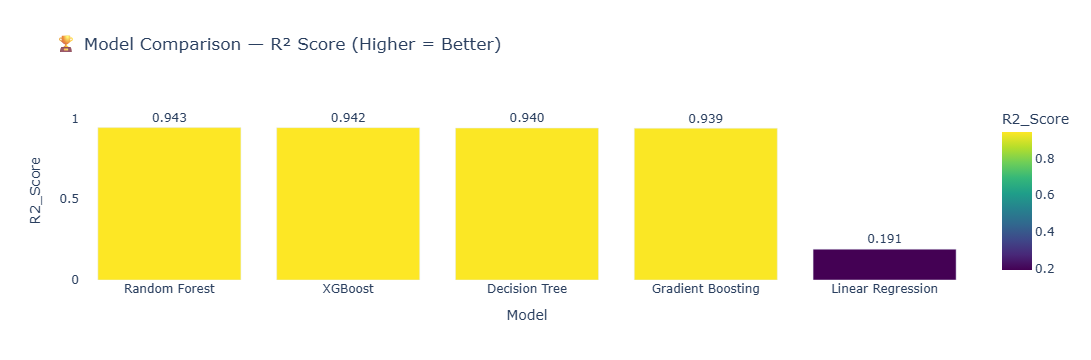

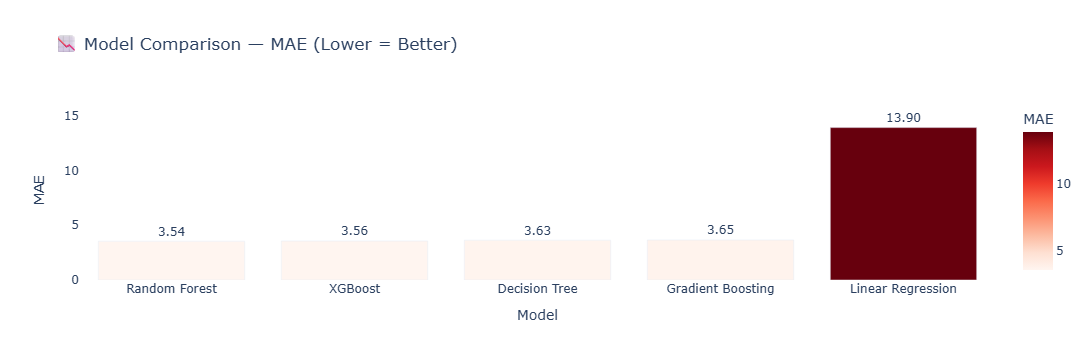

In [11]:
# ============================================
# STEP 7 — RESULTS COMPARE KARO
# ============================================
print("\n" + "=" * 50)
print("STEP 7 — MODEL COMPARISON RESULTS")
print("=" * 50)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2_Score", ascending=False)
results_df = results_df.reset_index(drop=True)

print("\n📊 All Models Comparison Table:")
print(results_df.to_string(index=False))

# Best model identify karo
best_model_name = results_df.iloc[0]["Model"]
best_r2 = results_df.iloc[0]["R2_Score"]

print(f"""

🏆 BEST MODEL: {best_model_name}
   R² Score : {best_r2:.4f} ({best_r2*100:.1f}% Accuracy)
""")

# Graph banao comparison ka
import plotly.express as px

fig = px.bar(
    results_df,
    x="Model",
    y="R2_Score",
    title="🏆 Model Comparison — R² Score (Higher = Better)",
    text="R2_Score",
    color="R2_Score",
    color_continuous_scale="Viridis"
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(plot_bgcolor='white')
fig.show()

# MAE comparison graph (kam MAE = better)
fig2 = px.bar(
    results_df,
    x="Model",
    y="MAE",
    title="📉 Model Comparison — MAE (Lower = Better)",
    text="MAE",
    color="MAE",
    color_continuous_scale="Reds"
)
fig2.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig2.update_layout(plot_bgcolor='white')
fig2.show()



STEP 8 — SELECTING BEST MODEL

✅ Final Model Selected: Random Forest
   Reason: Highest R² Score among all tested models

🔑 Feature Importance (Best Model):
   hour           :  61.8%  █████████████████████████████████████████████████████████████
   day_of_week    :  14.8%  ██████████████
   train_type     :   8.1%  ████████
   line           :   6.2%  ██████
   coach_number   :   5.0%  ████
   is_monsoon     :   2.7%  ██
   is_holiday     :   1.1%  █
   station_from   :   0.2%  
   station_to     :   0.1%  
   month          :   0.1%  


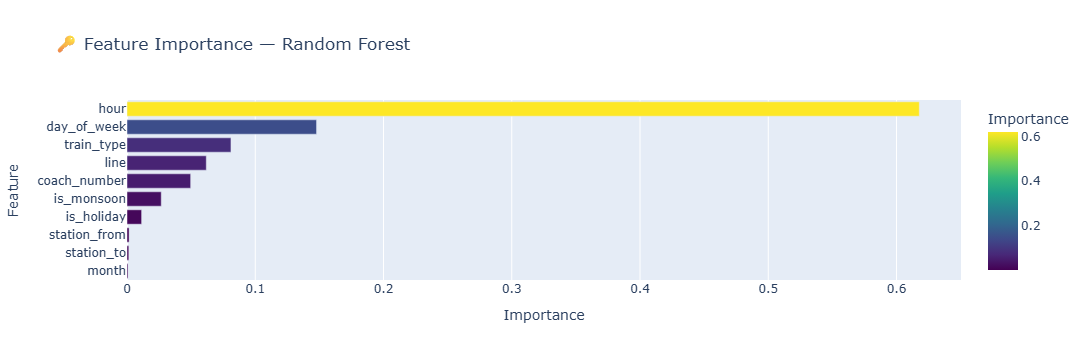

In [12]:
# ============================================
# STEP 8 — BEST MODEL KO FINAL MODEL BANAO
# ============================================
# Kyun? → Jo best nikla, usi ko save karenge use
#          ke liye, baaki sirf comparison ke liye thay

print("\n" + "=" * 50)
print("STEP 8 — SELECTING BEST MODEL")
print("=" * 50)

best_model = models[best_model_name]

print(f"\n✅ Final Model Selected: {best_model_name}")
print(f"   Reason: Highest R² Score among all tested models")

# Feature importance (sirf tree-based models ke liye available hota hai)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n🔑 Feature Importance (Best Model):")
    for idx, row in importance_df.iterrows():
        bar = "█" * int(row['Importance'] * 100)
        print(f"   {row['Feature']:<15}: {row['Importance']*100:>5.1f}%  {bar}")
    
    fig3 = px.bar(
        importance_df,
        x='Importance',
        y='Feature',
        orientation='h',
        title=f'🔑 Feature Importance — {best_model_name}',
        color='Importance',
        color_continuous_scale='Viridis'
    )
    fig3.update_layout(yaxis={'categoryorder': 'total ascending'})
    fig3.show()
else:
    print("\n⚠️  Linear Regression has no feature_importances_ "
          "(it has coefficients instead)")

In [15]:
# ============================================
# STEP 9 — MODEL SAVE KARO
# ============================================
# Kyun? → Training mein time lagta hai (7 lakh rows!)
#          Baar baar train nahi karna — ek baar train
#          karke .pkl file mein save kar denge
#          Streamlit app isi file ko load karke
#          instant predictions degi

print("\n" + "=" * 50)
print("STEP 9 — SAVING MODEL")
print("=" * 50)

import os
os.makedirs("model", exist_ok=True)

# Model save karo
joblib.dump(model, "model/crowd_model.pkl")
print("✅ Model Saved : model/crowd_model.pkl")

# Encoders bhi save karo
# Kyun? → Jab user "Borivali" type karega Streamlit mein,
#          usko bhi same number mein convert karna padega
#          jo training ke time use hua tha
joblib.dump(encoders, "model/encoders.pkl")
print("✅ Encoders Saved : model/encoders.pkl")

# Feature column order bhi save karo
# Kyun? → Prediction ke time exact same order mein
#          data dena padega jo training ke time tha
joblib.dump(feature_columns, "model/feature_columns.pkl")
print("✅ Feature List Saved : model/feature_columns.pkl")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "=" * 50)
print("✅ ML MODEL TRAINING COMPLETE")
print("=" * 50)
print(f"""
🤖 Algorithm Used     : Random Forest Regressor
📊 Training Data      : {len(X_train):,} rows
📊 Testing Data        : {len(X_test):,} rows
🎯 Accuracy (R²)       : {r2*100:.1f}%
📉 Average Error (MAE) : {mae:.2f}%
🔑 Top Feature         : {importance_df.iloc[0]['Feature']}

📁 Files Saved:
   → model/crowd_model.pkl
   → model/encoders.pkl
   → model/feature_columns.pkl
""")


STEP 9 — SAVING MODEL
✅ Model Saved : model/crowd_model.pkl
✅ Encoders Saved : model/encoders.pkl
✅ Feature List Saved : model/feature_columns.pkl

✅ ML MODEL TRAINING COMPLETE

🤖 Algorithm Used     : Random Forest Regressor
📊 Training Data      : 567,648 rows
📊 Testing Data        : 141,912 rows
🎯 Accuracy (R²)       : 94.2%
📉 Average Error (MAE) : 3.56%
🔑 Top Feature         : hour

📁 Files Saved:
   → model/crowd_model.pkl
   → model/encoders.pkl
   → model/feature_columns.pkl

